In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load best models
rf_fraud = joblib.load('../models/rf_fraud.pkl')
xgb_cc = joblib.load('../models/xgb_cc.pkl')

# Load test data
X_test_f = pd.read_csv('../data/processed/X_test_fraud.csv')
y_test_f = pd.read_csv('../data/processed/y_test_fraud.csv').squeeze()

X_test_cc = pd.read_csv('../data/processed/X_test_cc.csv')
y_test_cc = pd.read_csv('../data/processed/y_test_cc.csv').squeeze()

print("Models and data loaded!")

Models and data loaded!


In [2]:
# Use a sample for speed
X_sample_f = X_test_f.sample(500, random_state=42)

explainer_f = shap.TreeExplainer(rf_fraud)
shap_values_f = explainer_f.shap_values(X_sample_f)

# For binary classification, shap_values is a list — take class 1 (fraud)
shap_fraud = shap_values_f[:, :, 1] if len(np.array(shap_values_f).shape) == 3 else shap_values_f[1]

print("SHAP values computed for Fraud Data!")
print("Shape:", np.array(shap_fraud).shape)

SHAP values computed for Fraud Data!
Shape: (500, 194)


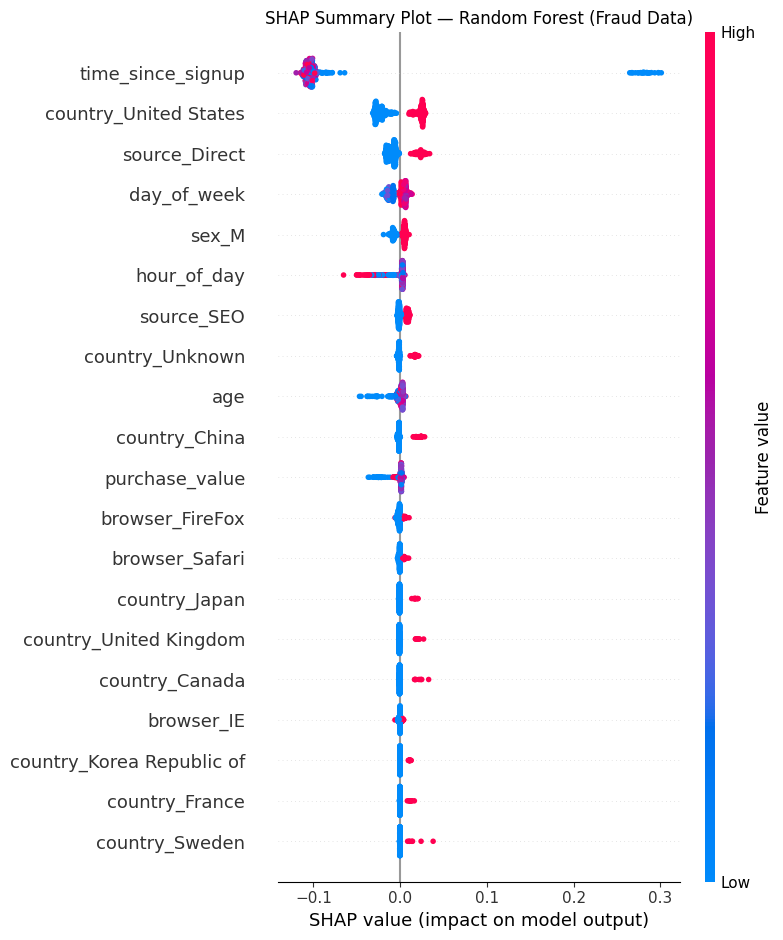

Summary plot saved!


In [3]:
plt.figure()
shap.summary_plot(shap_fraud, X_sample_f, show=False)
plt.title("SHAP Summary Plot — Random Forest (Fraud Data)")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_fraud.png', bbox_inches='tight')
plt.show()
print("Summary plot saved!")

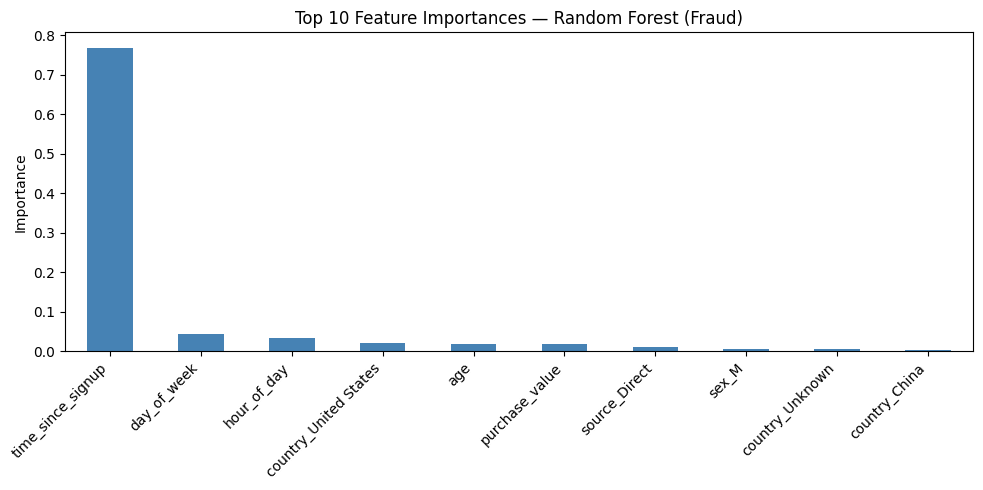

In [4]:
feat_imp = pd.Series(rf_fraud.feature_importances_, index=X_test_f.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest (Fraud)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_fraud.png')
plt.show()

In [5]:
# Get predictions on sample
y_sample = y_test_f.loc[X_sample_f.index]
y_pred_sample = rf_fraud.predict(X_sample_f)

# True Positive — actual fraud, predicted fraud
tp_idx = X_sample_f[(y_sample.values == 1) & (y_pred_sample == 1)].index[0]
# False Positive — actual legit, predicted fraud  
fp_idx = X_sample_f[(y_sample.values == 0) & (y_pred_sample == 1)].index[0]
# False Negative — actual fraud, predicted legit
fn_idx = X_sample_f[(y_sample.values == 1) & (y_pred_sample == 0)].index[0]

print("True Positive index:", tp_idx)
print("False Positive index:", fp_idx)
print("False Negative index:", fn_idx)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [6]:
shap.initjs()

# Get position in sample dataframe
tp_pos = X_sample_f.index.get_loc(tp_idx)
fp_pos = X_sample_f.index.get_loc(fp_idx)
fn_pos = X_sample_f.index.get_loc(fn_idx)

base_val = explainer_f.expected_value
if isinstance(base_val, list): base_val = base_val[1]

# True Positive
print("=== TRUE POSITIVE (Correctly Identified Fraud) ===")
shap.force_plot(base_val, shap_fraud[tp_pos], X_sample_f.iloc[tp_pos], matplotlib=True, show=False)
plt.title("Force Plot — True Positive")
plt.tight_layout()
plt.savefig('../data/processed/force_plot_tp.png', bbox_inches='tight')
plt.show()

# False Positive
print("=== FALSE POSITIVE (Legit flagged as Fraud) ===")
shap.force_plot(base_val, shap_fraud[fp_pos], X_sample_f.iloc[fp_pos], matplotlib=True, show=False)
plt.title("Force Plot — False Positive")
plt.tight_layout()
plt.savefig('../data/processed/force_plot_fp.png', bbox_inches='tight')
plt.show()

# False Negative
print("=== FALSE NEGATIVE (Missed Fraud) ===")
shap.force_plot(base_val, shap_fraud[fn_pos], X_sample_f.iloc[fn_pos], matplotlib=True, show=False)
plt.title("Force Plot — False Negative")
plt.tight_layout()
plt.savefig('../data/processed/force_plot_fn.png', bbox_inches='tight')
plt.show()

NameError: name 'fp_idx' is not defined

In [ ]:
X_sample_cc = X_test_cc.sample(500, random_state=42)

explainer_cc = shap.TreeExplainer(xgb_cc)
shap_values_cc = explainer_cc.shap_values(X_sample_cc)

plt.figure()
shap.summary_plot(shap_values_cc, X_sample_cc, show=False)
plt.title("SHAP Summary Plot — XGBoost (Credit Card Data)")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_cc.png', bbox_inches='tight')
plt.show()
print("Credit card SHAP done!")